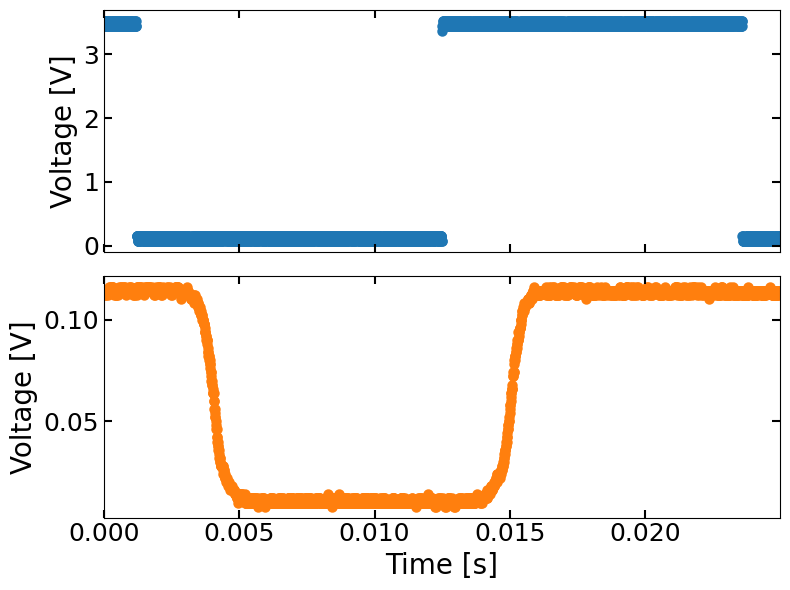

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_oscilloscope_csv(file_path, skip_rows=0):    
    try:
        df = pd.read_csv(file_path, skiprows=skip_rows)
    except Exception as e:
        print(f"エラー: ファイルを読み込めませんでした。\n{e}")
        return

    columns = df.columns
    
    time_col = columns[0]
    channel_cols = columns[1:]
    
    num_channels = len(channel_cols)
    
    fig, axes = plt.subplots(nrows=num_channels, ncols=1, sharex=True, figsize=(8, 6))
    
    if num_channels == 1:
        axes = [axes]

    # --- 3. 各チャンネルのプロット ---
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

    # ★変更点1: 時間データの最小値を取得（これを引くことで0スタートにする）
    time_offset = df[time_col].min()

    for i, col_name in enumerate(channel_cols):
        ax = axes[i]
        
        # ★変更点2: 時間データから最小値を引く
        x_data = df[time_col] - time_offset
        y_data = df[col_name]
        
        ax.scatter(x_data, y_data, label=col_name, color=colors[i % len(colors)], linewidth=1.5)
        
        ax.set_ylabel('Voltage [V]', fontsize=20)
        ax.grid(False)

        # 目盛りの設定（内側・大きく）
        ax.tick_params(
            axis='both', 
            which='major', 
            direction='in', 
            labelsize=18, 
            length=6, 
            width=1.5,
            top=True, 
            right=True
        )

    # ★変更点3: 横軸の表示範囲を明示的に0からにする
    axes[-1].set_xlim(left=0, right=x_data.max())
    # axes[-1].set_xlim(left=0, right=0.025)
    
    axes[-1].set_xlabel('Time [s]', fontsize=20)
    
    plt.tight_layout()
    plt.show()

# --- 実行部分 ---
if __name__ == "__main__":
    csv_file = "C:\\Users\\shiori\\Desktop\\ion_control_shutter_camera\\src\\waveform\\output\\20251016_154217_waveform.csv" 
    
    plot_oscilloscope_csv(csv_file, skip_rows=0)

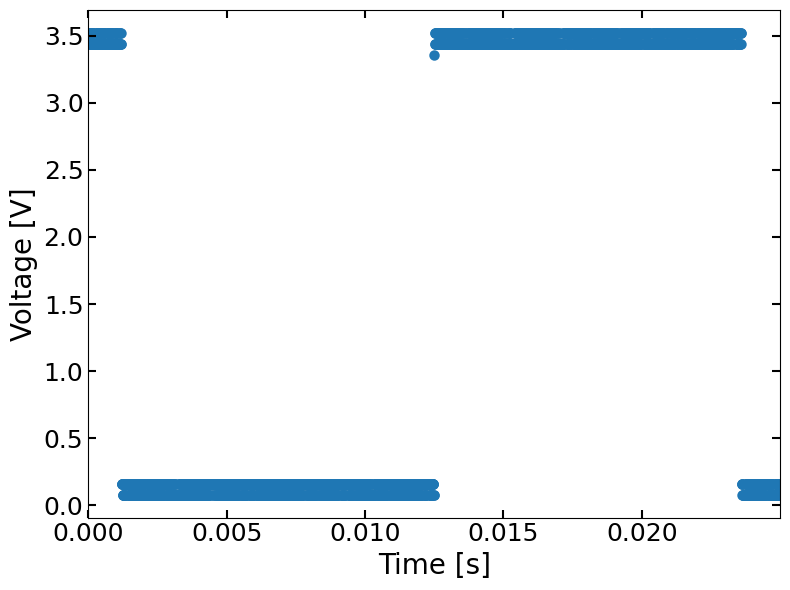

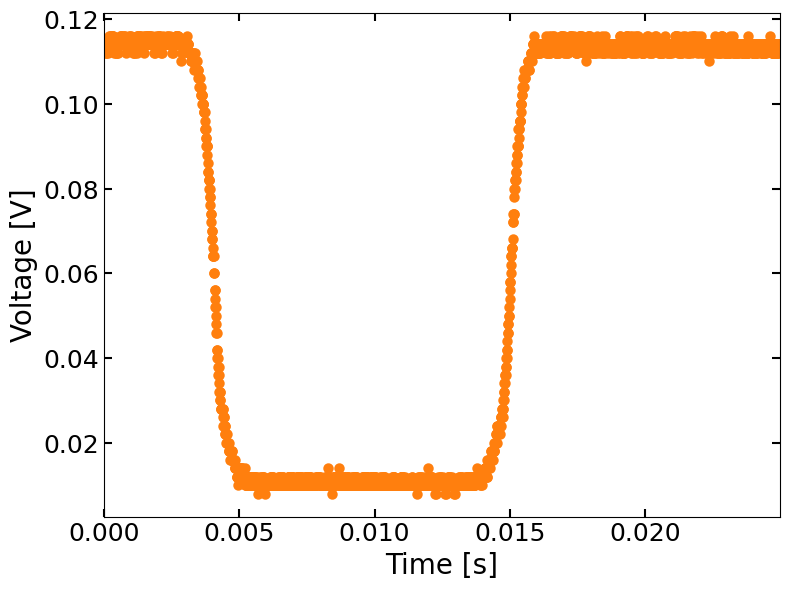

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_oscilloscope_csv(file_path, skip_rows=0):    
    try:
        df = pd.read_csv(file_path, skiprows=skip_rows)
    except Exception as e:
        print(f"エラー: ファイルを読み込めませんでした。\n{e}")
        return

    columns = df.columns
    
    time_col = columns[0]
    channel_cols = columns[1:]
    
    # 配色リスト
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

    # 時間データの最小値を取得（オフセット用）
    time_offset = df[time_col].min()

    # --- チャンネルごとにループして別々の図を作成 ---
    for i, col_name in enumerate(channel_cols):
        
        # ★変更点: ループの中で毎回新しい figure と ax を作成する
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # 時間データから最小値を引く（0スタート）
        x_data = df[time_col] - time_offset
        y_data = df[col_name]
        
        # プロット
        ax.scatter(x_data, y_data, label=col_name, color=colors[i % len(colors)], linewidth=1.5)
        
        # 軸ラベル設定（すべてのグラフに必要なのでループ内で設定）
        ax.set_ylabel('Voltage [V]', fontsize=20)
        ax.set_xlabel('Time [s]', fontsize=20)
        
        ax.grid(False)

        # 目盛りの設定（内側・大きく）
        ax.tick_params(
            axis='both', 
            which='major', 
            direction='in', 
            labelsize=18, 
            length=6, 
            width=1.5,
            top=True, 
            right=True
        )

        # 横軸の表示範囲設定
        ax.set_xlim(left=0, right=x_data.max())
        # ax.set_xlim(left=0, right=0.025)
        
        # タイトルが必要な場合は以下のように追加できます
        # ax.set_title(col_name, fontsize=16)

        plt.tight_layout()

    # すべてのウィンドウを表示
    plt.show()

# --- 実行部分 ---
if __name__ == "__main__":
    csv_file = "C:\\Users\\shiori\\Desktop\\ion_control_shutter_camera\\src\\waveform\\output\\20251016_154217_waveform.csv" 
    
    plot_oscilloscope_csv(csv_file, skip_rows=0)

In [ ]:
    csv_file = "C:\\Users\\shiori\\Desktop\\ion_control_shutter_camera\\src\\waveform\\output\\20251107_114825_waveform.csv" 
    csv_file = "C:\\Users\\shiori\\Desktop\\ion_control_shutter_camera\\src\\waveform\\output\\20251024_181940_waveform.csv" 
    csv_file = "C:\\Users\\shiori\\Desktop\\ion_control_shutter_camera\\src\\waveform\\output\\20251016_154217_waveform.csv" 
